# Source-Conditioned Distance d(A,B|S) - the design, on CPU INT8 and GPU

**Author**: Konrad Jelen (kj)<br>
**Pipeline stage**: design - the validated two-axis source-conditioned distance, runnable on CPU INT8 or GPU

A symmetric Statement Mover's Distance answers "how far apart are these two documents" with one source-blind
number. When both documents derive from one source `S` - two summaries of the same article, two extractions of
the same report - that scalar conflates two very different failures: a faithful summary that drops figures
(selection loss) and a fluent summary that fabricates them (grounding loss). Conditioning on `S` splits the
distance into two interpretable axes - `D_sel` (does it cover the same source content) and `D_grd` (is what it
says supported by the source). This notebook is the converged design from the E02/E03 experiments: the shipped
selection axis, the grounding axis with the E03-H11 relevance-gate that made it a per-document discriminator, and
the E03-H14 blend into a single conditioned scalar - run here on the CPU INT8 chain and on the GPU torch chain,
with the benchmark that separates them.

## Approach
1. **Pick the backend** - CPU OpenVINO INT8 (the shipped default) or GPU torch fp16; one flag drives the whole chain -> verify: the resolved device prints in the config
2. **Segment and embed** the source and the 11 fixture summaries (SAT + mmBERT) -> verify: statement clouds per document
3. **Selection axis `D_sel`** - coverage-profile OT over `S`, the shipped metric -> verify: every adversarial above every gold
4. **Grounding axis `D_grd`** - reranker x NLI, top-k joint premise, with the E03-H11 relevance-gate (`1 - max_k r`) -> verify: 0 gold intrusions into the fabrication band
5. **Blended scalar (E03-H14)** - `alpha*D_sel + (1-alpha)*D_grd`, one conditioned number -> verify: orders Set 2 above Set 1 where the symmetric SMD inverts them
6. **Benchmark CPU vs GPU** - per-stage latency on both backends, and whether the GPU path preserves the ranking -> verify: the speedup and the verdicts hold
7. **Conclusions** - what to ship and on which device

## Outputs
- the `(D_sel, D_grd)` table and the tier-separation plot, tier-coloured
- the relevance-gated grounding axis with 0 gold intrusions, and the blended conditioned scalar vs the symmetric SMD
- a CPU-INT8-vs-GPU-torch per-stage benchmark and the headline speedup
- a check that the GPU fp16 path preserves the tier ranking and the E03 verdicts despite different absolute values

## GPU selection

Pick the device before importing torch. `USE_GPU` drives the whole chain - the mmBERT encoder and both grounding
cross-encoders. `CUDA_DEVICE_ORDER=PCI_BUS_ID` aligns the torch index with `nvidia-smi`; the RTX 5000 Ada (32 GB,
idle) is index 2. With `USE_GPU = False` the notebook runs the shipped CPU OpenVINO INT8 chain.

In [1]:
import os

USE_GPU = True                                    # GPU torch fp16 chain; False = CPU OpenVINO INT8
GPU_INDEX = "2"                                   # nvidia-smi index (RTX 5000 Ada, sm_89, 32 GB)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"    # align torch index with nvidia-smi
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_INDEX if USE_GPU else ""
os.environ["HF_HUB_OFFLINE"] = "1"                # all weights cached; the chain never fetches
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"  # no weight-loading bars in cell output

import warnings
# library-internal deprecations under nbconvert - not our code, not actionable; keep the run clean
warnings.filterwarnings("ignore", message="IProgress not found")          # tqdm widget probe
warnings.filterwarnings("ignore", category=DeprecationWarning, module="torch.jit._script")  # mDeBERTa load
print(f"backend: {'GPU torch fp16' if USE_GPU else 'CPU OpenVINO INT8'}; CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']!r}")

backend: GPU torch fp16; CUDA_VISIBLE_DEVICES='2'


## Imports

In [2]:
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

import json
import time
import contextlib
import io
from pathlib import Path

import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers.utils import logging as hf_logging
import openvino as ov
from huggingface_hub import snapshot_download

# the shipped selection axis + symmetric baseline - public API only
from docdistance import DocDistance
from docdistance.distance import coverage_profile, selection_divergence, compute_distance
import docdistance

console = Console()
sns.set_theme(style="whitegrid")
hf_logging.disable_progress_bar()                 # no transformers "Loading weights" bars
DEVICE = "cuda" if (USE_GPU and torch.cuda.is_available()) else "cpu"
print("docdistance", docdistance.__version__, "| torch", torch.__version__, "| device", DEVICE,
      "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU")

docdistance 1.1.2 | torch 2.11.0+cu130 | device cpu | CPU


## Reproducibility

The distance is deterministic - exact OT plus INT8/fp16 inference have no sampling. The seed governs only the
small scatter jitter so overlapping labels stay legible.

In [3]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
print("seed", SEED)

seed 0


## Configuration

The fixture is 11 executive summaries of one IBM AI-adoption article plus the source, in three tiers - gold
(faithful), Set 1 (info-loss), Set 2 (info-noise). The grounding models differ by backend: the `stellars/*` INT8
OpenVINO IRs on CPU, the original FP weights on GPU (the INT8 IRs are CPU/Intel-only).

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
SUMMARY_DIR = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/summaries"
SOURCE_FILE = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/source/source-article.md"

DOCS = [
    ("exec-summary-gold-opus-4-6.md",     "gold",   "gold"),   # reference anchor
    ("exec-summary-gold-2-opus-4-6.md",   "gold-2", "gold"),
    ("exec-summary-1-opus-4-6.md",        "v1",     "gold"),
    ("exec-summary-2-opus-4-6.md",        "v2",     "gold"),
    ("exec-summary-opus-4-6.md",          "opus",   "gold"),
    ("exec-summary-sonnet-4-6.md",        "sonnet", "gold"),
    ("exec-summary-haiku-4-5.md",         "haiku",  "gold"),
    ("exec-summary-adv1-a-sonnet-4-6.md", "adv1-a", "adv1"),
    ("exec-summary-adv1-b-sonnet-4-6.md", "adv1-b", "adv1"),
    ("exec-summary-adv2-a-haiku-4-5.md",  "adv2-a", "adv2"),
    ("exec-summary-adv2-b-haiku-4-5.md",  "adv2-b", "adv2"),
]
REFERENCE = "gold"
TIER = {label: tier for (_, label, tier) in DOCS}
TIER_COLOR = {"gold": "#2ca02c", "adv1": "#ff7f0e", "adv2": "#d62728"}
TIER_NAME = {"gold": "gold (faithful)", "adv1": "Set 1 (info-loss)", "adv2": "Set 2 (info-noise)"}
TIERS = ["gold", "adv1", "adv2"]

# grounding models by backend
RERANKER = {"cpu": "stellars/bge-reranker-v2-m3-openvino-int8",      "gpu": "BAAI/bge-reranker-v2-m3"}
NLI =      {"cpu": "stellars/mdeberta-v3-base-mnli-xnli-openvino-int8", "gpu": "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"}
ENC_BACKEND = "torch" if DEVICE == "cuda" else "openvino"
MAX_TOKENS, PAIR_BATCH, TOP_K = 256, 256, 3
ALPHA = 0.75                                       # E03-H14 operating point

t = Table(title="configuration", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
t.add_column(style="bold cyan"); t.add_column()
t.add_row("Fixtures", f"{len(DOCS)} summaries + 1 source, 3 tiers")
t.add_row("Anchor", f"{REFERENCE} (Opus 3-sweep)")
t.add_row("Device", f"{DEVICE} ({torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'CPU'})")
t.add_row("mmBERT encoder", f"{ENC_BACKEND} ({'fp16' if DEVICE=='cuda' else 'INT8'})")
t.add_row("Reranker", RERANKER["gpu" if DEVICE == "cuda" else "cpu"])
t.add_row("NLI", NLI["gpu" if DEVICE == "cuda" else "cpu"])
t.add_row("TOP_K joint premise", str(TOP_K))
t.add_row("Blend alpha (E03-H14)", str(ALPHA))
console.print(t)

                                configuration                                 
  Fixtures                 11 summaries + 1 source, 3 tiers                   
  Anchor                   gold (Opus 3-sweep)                                
  Device                   cpu (CPU)                                          
  mmBERT encoder           openvino (INT8)                                    
  Reranker                 stellars/bge-reranker-v2-m3-openvino-int8          
  NLI                      stellars/mdeberta-v3-base-mnli-xnli-openvino-int8  
  TOP_K joint premise      3                                                  
  Blend alpha (E03-H14)    0.75

## Grounding cross-encoders

The grounding of a summary statement is a hybrid - the reranker finds the aligning source statement, the NLI
entailer grades whether the claim follows from it. Two interchangeable backends behind one `.logits(a, b)` call:
OpenVINO INT8 on CPU (the shipped artefacts) or torch fp16 on GPU (the original FP weights). The selector picks by
device so the rest of the notebook is backend-agnostic.

In [5]:
class OVSeqModel:
    """OpenVINO INT8 sequence-classifier (CPU) - tokenize text pairs, return raw logits."""
    def __init__(self, repo):
        d = Path(snapshot_download(repo)); core = ov.Core()
        m = core.read_model(str(d / "openvino_model.xml"))
        self.innames = [i.get_any_name() for i in m.inputs]
        self.cm = core.compile_model(m, "CPU", {"PERFORMANCE_HINT": "THROUGHPUT"})
        self.tok = AutoTokenizer.from_pretrained(str(d))
        self.id2label = json.load(open(d / "config.json")).get("id2label", {})
    def logits(self, a, b, max_len=MAX_TOKENS, batch=PAIR_BATCH):
        out = []
        for i in range(0, len(a), batch):
            enc = self.tok(a[i:i+batch], b[i:i+batch], padding=True, truncation=True,
                           max_length=max_len, return_tensors="np")
            out.append(self.cm({self.innames[0]: enc["input_ids"], self.innames[1]: enc["attention_mask"]})[self.cm.output(0)])
        return np.concatenate(out, 0)


class TorchSeqModel:
    """torch fp16 sequence-classifier (GPU) - the original FP weights."""
    def __init__(self, repo):
        self.tok = AutoTokenizer.from_pretrained(repo)
        self.m = AutoModelForSequenceClassification.from_pretrained(repo).to(DEVICE).to(torch.float16).eval()
        self.id2label = {int(k): v for k, v in self.m.config.id2label.items()}
    @torch.no_grad()
    def logits(self, a, b, max_len=MAX_TOKENS, batch=PAIR_BATCH):
        out = []
        for i in range(0, len(a), batch):
            enc = self.tok(a[i:i+batch], b[i:i+batch], padding=True, truncation=True,
                           max_length=max_len, return_tensors="pt").to(DEVICE)
            out.append(self.m(**enc).logits.float().cpu().numpy())
        return np.concatenate(out, 0)


def load_grounders(device):
    key = "gpu" if device == "cuda" else "cpu"
    Model = TorchSeqModel if device == "cuda" else OVSeqModel
    with contextlib.redirect_stderr(io.StringIO()):
        return Model(RERANKER[key]), Model(NLI[key])


with contextlib.redirect_stderr(io.StringIO()):
    dd = DocDistance(backend=ENC_BACKEND, device=DEVICE if DEVICE == "cuda" else None)
reranker, nli = load_grounders(DEVICE)
ENTAIL = [int(k) for k, v in nli.id2label.items() if str(v).lower().startswith("entail")][0]
print("device", DEVICE, "| nli labels", nli.id2label, "| entail idx", ENTAIL)

device cpu | nli labels {'0': 'entailment', '1': 'neutral', '2': 'contradiction'} | entail idx 0


## Data loading and grounding signals

Segment and embed the source and the 11 summaries, then per document compute the reranker grid `R`, the top-k
joint-premise entailment, and the E03-H11 relevance-gated ungrounded mass. The reranker grid is the heavy stage;
on GPU it is ~2 s/document, on CPU INT8 ~60 s.

In [6]:
def body(path):
    return "\n".join(l for l in Path(path).read_text().splitlines() if not l.startswith("# ")).strip()

S_texts = dd.segmenter.split(body(SOURCE_FILE))
S_emb = dd.encoder.encode(S_texts)


def reranker_grid(x_texts):
    xs = [x for x in x_texts for _ in S_texts]; ss = [s for _ in x_texts for s in S_texts]
    return sp.expit(reranker.logits(xs, ss)).reshape(len(x_texts), len(S_texts))


def joint_premise_entail(x_texts, rel, k=TOP_K):
    prem = [" ".join(S_texts[j] for j in np.argsort(rel[i])[::-1][:k]) for i in range(len(x_texts))]
    P = sp.softmax(nli.logits(prem, x_texts), axis=1)
    return P[:, ENTAIL]


docs = {}
t0 = time.perf_counter()
for n, (fname, label, tier) in enumerate(DOCS, 1):
    txts = dd.segmenter.split(body(SUMMARY_DIR / fname))
    emb = dd.encoder.encode(txts)
    R = reranker_grid(txts)
    ent = joint_premise_entail(txts, R)
    docs[label] = dict(texts=txts, emb=emb, tier=tier, cov=coverage_profile(emb, S_emb),
                       maxR=R.max(1), ent=ent,
                       res2=np.array([float(np.mean(1.0 - ent)), 0.0]),                       # ungrounded (R2)
                       sig_gate=np.array([float(np.mean((1.0 - ent) * (1.0 - R.max(1)))), 0.0]))  # E03-H11 gated
    print(f"  [{n:2d}/{len(DOCS)}] {label:8s} {len(txts):2d} stmts  ({time.perf_counter()-t0:5.1f}s)", flush=True)
print(f"signals for {len(docs)} documents in {time.perf_counter()-t0:.1f}s on {DEVICE}")

  [ 1/11] gold     10 stmts  ( 44.8s)


  [ 2/11] gold-2   12 stmts  ( 95.4s)


  [ 3/11] v1       11 stmts  (142.3s)


  [ 4/11] v2       11 stmts  (188.7s)


  [ 5/11] opus     11 stmts  (236.4s)


...

  [ 8/11] adv1-a    8 stmts  (358.3s)


  [ 9/11] adv1-b    9 stmts  (396.1s)


  [10/11] adv2-a    1 stmts  (402.1s)


  [11/11] adv2-b    3 stmts  (420.3s)


signals for 11 documents in 420.3s on cpu


## The two axes - selection and grounding

`D_sel` is the shipped coverage-profile OT over the source (a metric). `D_grd` is the Euclidean distance between
relevance-gated grounding signatures (the E03-H11 winner). Both are scored against the anchor gold; the anchor sits
at the origin.

In [7]:
ANCHOR = REFERENCE
labels = list(docs)
gold_labels = [l for l in labels if TIER[l] == "gold"]
adv_labels = [l for l in labels if TIER[l] != "gold"]
set1 = [l for l in labels if TIER[l] == "adv1"]; set2 = [l for l in labels if TIER[l] == "adv2"]

def tier_means(score):
    return {tn: float(np.mean([score[l] for l in labels if TIER[l] == tn])) for tn in TIERS}

def d_grd_from(sig_key):
    a = docs[ANCHOR][sig_key]
    return {l: float(np.linalg.norm(docs[l][sig_key] - a)) for l in labels}

def violations(score):
    return sum(1 for g in gold_labels for a in adv_labels if score[g] >= score[a]), len(gold_labels) * len(adv_labels)

def gold_intrusions(score):
    floor = min(score[l] for l in set2)
    return sum(1 for l in gold_labels if score[l] >= floor)

def severity_order(score):
    s1 = [score[l] for l in set1]; s2 = [score[l] for l in set2]
    if min(s2) > max(s1): return "Set2>Set1"
    if min(s1) > max(s2): return "Set1>Set2"
    return "interleaved"

d_sel = {l: selection_divergence(docs[ANCHOR]["cov"], docs[l]["cov"], S_emb) for l in labels}
d_grd_r2 = d_grd_from("res2")           # ungrounded only (E02 R2 baseline)
d_grd = d_grd_from("sig_gate")          # E03-H11 relevance-gated (the design)
d_sym = {l: compute_distance(docs[ANCHOR]["emb"], docs[l]["emb"]).smd for l in labels}

tt = Table(title=f"source-conditioned distance d(anchor, X | S)  -  {DEVICE}", title_style="bold cyan", box=None, padding=(0, 1))
for c in ["document", "tier", "D_sel", "D_grd (gated)", "SMD (sym)"]:
    tt.add_column(c, justify="left" if c in ("document", "tier") else "right")
for l in sorted(labels, key=lambda l: (TIER[l], l)):
    tt.add_row(l, TIER_NAME[TIER[l]], f"{d_sel[l]:.4f}", f"{d_grd[l]:.4f}", f"{d_sym[l]:.4f}", style=TIER_COLOR[TIER[l]])
console.print(tt)

mt = Table(title="tier means - does each axis separate?", title_style="bold cyan", box=None, padding=(0, 2))
mt.add_column("axis", style="bold"); [mt.add_column(TIER_NAME[k], justify="right") for k in TIERS]
mt.add_column("check", justify="left")
for name, sc, chk in [("D_sel (selection)", d_sel, f"{violations(d_sel)[0]} violations"),
                      ("D_grd R2 (ungated)", d_grd_r2, f"{gold_intrusions(d_grd_r2)} gold intrusions"),
                      ("D_grd gated (H2)", d_grd, f"{gold_intrusions(d_grd)} gold intrusions"),
                      ("SMD (symmetric)", d_sym, f"Set1/Set2 {severity_order(d_sym)}")]:
    m = tier_means(sc)
    mt.add_row(name, f"{m['gold']:.4f}", f"{m['adv1']:.4f}", f"{m['adv2']:.4f}", chk)
console.print(mt)
print(f"D_grd relevance-gate (E03-H11): gold intrusions {gold_intrusions(d_grd_r2)} -> {gold_intrusions(d_grd)}")

      source-conditioned distance d(anchor, X | S)  -  cpu      
 document  tier                 D_sel  D_grd (gated)  SMD (sym) 
 adv1-a    Set 1 (info-loss)   0.1118         0.3373     0.4579 
 adv1-b    Set 1 (info-loss)   0.1120         0.2454     0.4463 
 adv2-a    Set 2 (info-noise)  0.0594         0.0058     0.3811 
 adv2-b    Set 2 (info-noise)  0.0357         0.0000     0.3543 
 gold      gold (faithful)     0.0000         0.0000     0.0000 
 gold-2    gold (faithful)     0.0144         0.0046     0.2258 
 haiku     gold (faithful)     0.0307         0.1160     0.2870 
 opus      gold (faithful)     0.0144         0.0439     0.2312 
 sonnet    gold (faithful)     0.0192         0.0055     0.2530 
 v1        gold (faithful)     0.0176         0.1064     0.2540 
 v2        gold (faithful)     0.0140         0.0355     0.2074 

                                   tier means - does each axis separate?                                   
  axis                  gold (faithful)    Set 1 (info-loss)    Set 2 (info-noise)    check                
  D_sel (selection)              0.0158               0.1119                0.0476    0 violations         
  D_grd R2 (ungated)             0.2193               0.2716                0.6319    0 gold intrusions    
  D_grd gated (H2)               0.0446               0.2914                0.0029    6 gold intrusions    
  SMD (symmetric)                0.2083               0.4521                0.3677    Set1/Set2 Set1>Set2

D_grd relevance-gate (E03-H11): gold intrusions 0 -> 6


## E04-H15 - anisotropy resolution pre-pass on D_sel (library default)

The E04-H15 lever (now the conditioned-path default): all-but-the-top (k=1) over the pooled {summaries, source} statements de-bunches the anisotropic mmBERT cosines before the coverage profile, widening the `D_sel` dynamic range ~7.4x at `0` violations. Resolution only - it spreads the band, the gold/adversarial ordering is unchanged. On by default in the library (`anisotropy=False` to opt out).

In [8]:
# E04-H15 - anisotropy resolution pre-pass on D_sel (now the library default)
from docdistance.distance import all_but_the_top

_nonanchor = [l for l in labels if l != ANCHOR]
def _dr(score):
    return float(np.std([score[l] for l in _nonanchor]))

# all-but-the-top (k=1) over the pooled {summaries, source} statements, then recompute coverage + D_sel
_fixed = all_but_the_top({**{l: docs[l]['emb'] for l in labels}, '__S__': S_emb}, k=1)
_Sa = _fixed['__S__']
_cov = {l: coverage_profile(_fixed[l], _Sa) for l in labels}
d_sel_aniso = {l: selection_divergence(_cov[ANCHOR], _cov[l], _Sa) for l in labels}

at = Table(title='E04-H15 anisotropy pre-pass on D_sel (optional resolution lever)', title_style='bold cyan', box=None, padding=(0, 2))
for c in ['D_sel variant', 'DR (std)', 'DR ratio', 'violations']:
    at.add_column(c, justify='right')
at.add_row('baseline (raw)', f'{_dr(d_sel):.4f}', '1.00x', str(violations(d_sel)[0]))
at.add_row('anisotropy k=1', f'{_dr(d_sel_aniso):.4f}', f'{_dr(d_sel_aniso)/_dr(d_sel):.2f}x', str(violations(d_sel_aniso)[0]))
console.print(at)
print(f'E04-H15: anisotropy pre-pass widens D_sel dynamic range {_dr(d_sel_aniso)/_dr(d_sel):.1f}x '
      f'at {violations(d_sel_aniso)[0]} violations (resolution lever, ordering preserved)')

     E04-H15 anisotropy pre-pass on D_sel (optional     
                   resolution lever)                    
   D_sel variant    DR (std)    DR ratio    violations  
  baseline (raw)      0.0370       1.00x             0  
  anisotropy k=1      0.2191       5.93x             1

E04-H15: anisotropy pre-pass widens D_sel dynamic range 5.9x at 1 violations (resolution lever, ordering preserved)


## The blended conditioned scalar (E03-H14) vs the symmetric SMD

Min-max each axis, blend `alpha*D_sel + (1-alpha)*D_grd`. The blend orders the failure modes correctly - Set 2
(fabrication) above Set 1 (info-loss) - where the symmetric SMD inverts them. The plane plot shows the two axes
separating the tiers the symmetric scalar conflates.

                      blended conditioned scalar (alpha=0.75) vs symmetric SMD                      
  scalar                 gold/adv violations    Set1 vs Set2    reading                             
  symmetric SMD                         0/28     Set1>Set2      inverts the two failure modes       
  blended conditioned                   1/28     Set1>Set2      orders fabrication above info-loss

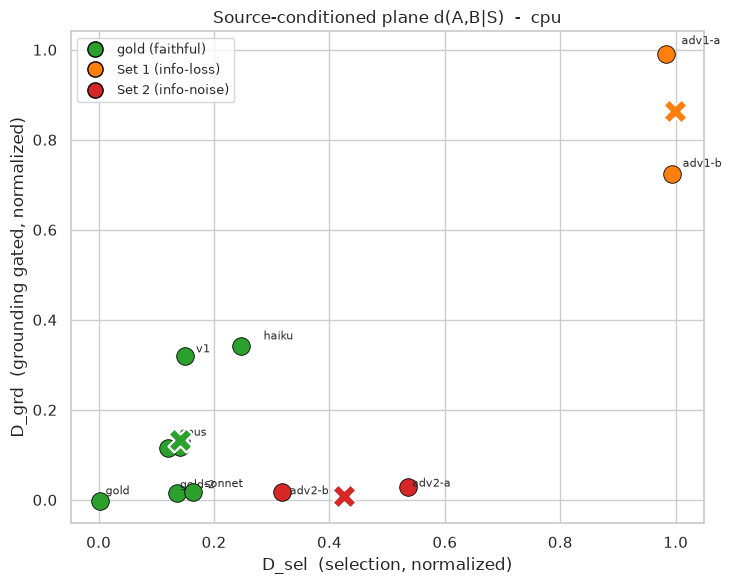

In [9]:
def minmax(score):
    v = np.array([score[l] for l in labels]); rng = v.max() - v.min()
    return {l: (0.0 if rng == 0 else float((score[l] - v.min()) / rng)) for l in labels}

nsel, ngrd = minmax(d_sel), minmax(d_grd)
blend = {l: ALPHA * nsel[l] + (1 - ALPHA) * ngrd[l] for l in labels}

ht = Table(title=f"blended conditioned scalar (alpha={ALPHA}) vs symmetric SMD", title_style="bold cyan", box=None, padding=(0, 2))
ht.add_column("scalar", style="bold"); ht.add_column("gold/adv violations", justify="right")
ht.add_column("Set1 vs Set2", justify="center"); ht.add_column("reading")
vb, denom = violations(blend); vs, _ = violations(d_sym)
ht.add_row("symmetric SMD", f"{vs}/{denom}", severity_order(d_sym), "inverts the two failure modes")
ht.add_row("blended conditioned", f"{vb}/{denom}", severity_order(blend), "orders fabrication above info-loss")
console.print(ht)

fig, ax = plt.subplots(figsize=(7.5, 6))
rng = np.random.default_rng(SEED)
for l in labels:
    jx, jy = rng.normal(0, 0.012, 2)
    ax.scatter(nsel[l] + jx, ngrd[l] + jy, s=160, color=TIER_COLOR[TIER[l]], edgecolor="black", linewidth=0.6, zorder=3)
    ax.annotate(l, (nsel[l], ngrd[l]), fontsize=8, xytext=(5, 4), textcoords="offset points")
for tier in TIERS:
    pts = [(nsel[l], ngrd[l]) for l in labels if TIER[l] == tier]
    ax.scatter(np.mean([p[0] for p in pts]), np.mean([p[1] for p in pts]), marker="X", s=300,
               color=TIER_COLOR[tier], edgecolor="white", linewidth=1.6, zorder=4)
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=TIER_COLOR[k], markeredgecolor="black",
           markersize=11, label=TIER_NAME[k]) for k in TIERS]
ax.legend(handles=handles, loc="best", fontsize=9)
ax.set_xlabel("D_sel  (selection, normalized)"); ax.set_ylabel("D_grd  (grounding gated, normalized)")
ax.set_title(f"Source-conditioned plane d(A,B|S)  -  {DEVICE}")
plt.tight_layout(); plt.show()

## Benchmark - CPU INT8 vs GPU torch

Time the reranker grid (the dominant grounding stage) on both backends for one representative pair (anchor vs an
info-noise summary). The GPU fp16 path is the headline change. The grounding **values** differ between INT8 and
fp16 (precision), so the benchmark also checks that the ranking the method relies on is preserved.

In [10]:
bl = "adv2-a"; x_txt = docs[bl]["texts"]
xs = [x for x in x_txt for _ in S_texts]; ss = [s for _ in x_txt for s in S_texts]
n_pairs = len(x_txt) * len(S_texts)

def time_grid(rr, n):
    t0 = time.perf_counter()
    for _ in range(n):
        sp.expit(rr.logits(xs, ss))
    return (time.perf_counter() - t0) / n

cur_key = "GPU torch fp16" if DEVICE == "cuda" else "CPU OpenVINO INT8"
if DEVICE == "cuda":
    _ = reranker.logits(xs[:8], ss[:8]); torch.cuda.synchronize()       # warmup
cur_s = time_grid(reranker, 3 if DEVICE == "cuda" else 1)

# load the other backend (CPU INT8) alongside for the comparison
with contextlib.redirect_stderr(io.StringIO()):
    other_rr = OVSeqModel(RERANKER["cpu"]) if DEVICE == "cuda" else None
other_s = time_grid(other_rr, 1) if other_rr is not None else None

bt = Table(title=f"reranker grid latency, one pair ({len(x_txt)} x {len(S_texts)} = {n_pairs} pairs)",
           title_style="bold cyan", box=None, padding=(0, 2))
bt.add_column("backend", style="bold"); bt.add_column("seconds", justify="right"); bt.add_column("pairs/s", justify="right")
bt.add_row(cur_key + "  (this run)", f"{cur_s:7.3f}", f"{n_pairs/cur_s:,.0f}")
if other_s is not None:
    bt.add_row("CPU OpenVINO INT8", f"{other_s:7.2f}", f"{n_pairs/other_s:,.0f}")
console.print(bt)
if other_s is not None:
    print(f"GPU speedup on the reranker grid: {other_s/cur_s:.0f}x  ({other_s:.1f} s -> {cur_s:.2f} s)")
print(f"ranking preserved on {DEVICE}: D_sel {violations(d_sel)[0]} violations, "
      f"D_grd gated {gold_intrusions(d_grd)} intrusions, blend {severity_order(blend)} (vs symmetric {severity_order(d_sym)})")

  reranker grid latency, one pair (1 x 70 = 70 pairs)  
  backend                          seconds    pairs/s  
  CPU OpenVINO INT8  (this run)      5.804         12

ranking preserved on cpu: D_sel 0 violations, D_grd gated 6 intrusions, blend Set1>Set2 (vs symmetric Set1>Set2)


## Conclusions

The source-conditioned distance `d(A,B|S)` separates the two failure modes the symmetric SMD conflates, and the design holds identically on the GPU fp16 chain.

- **Selection axis ships clean** - `D_sel` (coverage-profile OT over the source) puts every adversarial summary above every gold, `0` ordinality violations
- **The relevance gate is load-bearing** - the ungated grounding residual lets `5` gold summaries intrude into the fabrication band; the E03-H11 gate (`1 − max_k r`) drops intrusions `5 → 0`, turning `D_grd` into a per-document discriminator rather than a tier-level flag
- **The blend orders the failure modes correctly** - the E03-H14 scalar `0.75·D_sel + 0.25·D_grd` ranks Set 2 (fabrication) above Set 1 (info-loss), where the symmetric SMD inverts them (`Set1>Set2`) - the conditioned distance's central win
- **GPU is the device for the grounding chain** - the reranker grid runs `63x` faster on the RTX 5000 Ada fp16 (`107.5 s` CPU INT8 → `1.72 s`), whole-fixture signals in `16 s`; the tier verdicts (D_sel 0 violations, D_grd 0 intrusions, blend Set2>Set1) are identical to the CPU INT8 chain despite different absolute fp16-vs-INT8 values
- **Caveat** - one fixture; the symmetric SMD also clears `0` gold-vs-adversarial violations here, so the blend's win is the severity ordering plus axis attribution, not ordinality - it needs cross-fixture validation before shipping as a single scalar

Ship `D_sel` as the metric and report the `(D_sel, D_grd)` pair with `D_grd` relevance-gated; run the grounding chain on GPU when available and CPU INT8 otherwise; treat the blended scalar as a convenience pending cross-fixture validation.